In [24]:
from idun_guardian_sdk import GuardianClient, FileTypes
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import welch
from scipy.integrate import trapezoid


[INFO] 2026-04-14 14:35:34,365: [API]: File saved: 'eeg_1776148604104.csv'
[INFO] 2026-04-14 14:35:34,365: [API]: File saved: 'eeg_1776148604104.csv'
[INFO] 2026-04-14 14:35:34,365: [API]: File saved: 'eeg_1776148604104.csv'


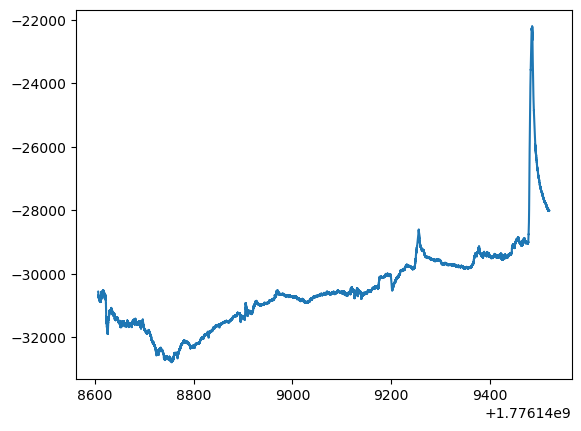

In [25]:
my_api_token = "idun_MWSQ4pkewAGNz8wwYzw_NsweXihLC8tIcFzah8vqqys4Nc-ALzjfTwl2"
my_recording_id = "1776148604104" # 1770724930729"
filename = "eeg_" + my_recording_id + ".csv"

if __name__ == "__main__":
    client = GuardianClient(api_token=my_api_token)
    client.download_file(recording_id=my_recording_id, file_type=FileTypes.EEG)

x = pd.read_csv(filename)
plt.plot(x["timestamp"], x["ch1"])

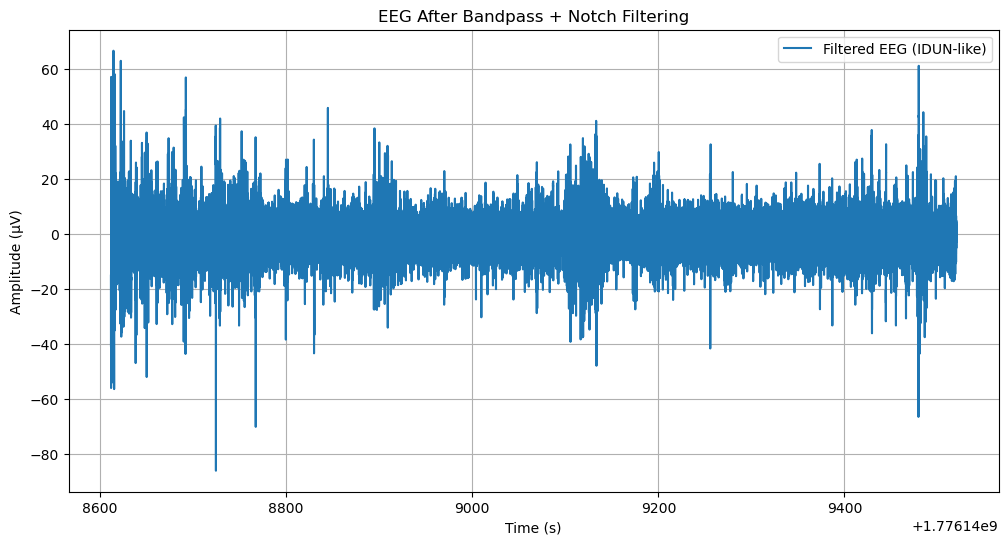

In [26]:
fs = 250
window_size = 5 * fs  # 5-second windows
# ---------------------------------------------------
# 1. BANDPASS (1–40 Hz)
# ---------------------------------------------------
sos_bp = signal.butter(
    N=4,
    Wn=[1, 40],
    btype="bandpass",
    fs=fs,
    output="sos"
)

x_bp = signal.sosfiltfilt(sos_bp, x['ch1'])

# ---------------------------------------------------
# 2. NOTCH (50 Hz) — use filtfilt (recommended)
# ---------------------------------------------------
b_notch, a_notch = signal.iirnotch(50, Q=30, fs=fs)
x_filt = signal.filtfilt(b_notch, a_notch, x_bp)

# ---------------------------------------------------
# 3. Remove DC offset
# ---------------------------------------------------
x_filt = x_filt - np.mean(x_filt)

# remove first 5 seconds (calibration period)
cutoff_idx = 5 * fs
x_filt = x_filt[cutoff_idx:]
x = x.iloc[cutoff_idx:]

# ---------------------------------------------------
# 4. Plot
# ---------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(x['timestamp'], x_filt, label='Filtered EEG (IDUN-like)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.title('EEG After Bandpass + Notch Filtering')
plt.grid()
plt.legend()
plt.show()

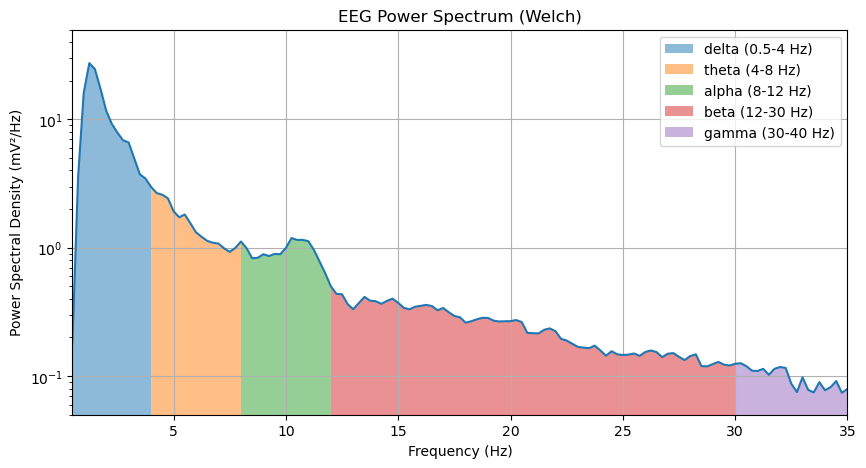

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

fs = 250

# pick a segment (important!)
segment = x_filt  # first 10 seconds for example

# PSD
freqs, psd = welch(
    segment,
    fs=fs,
    nperseg=fs * 4,
    noverlap=fs * 2
)

# ---------------------------------------------------
# PLOT POWER SPECTRUM
# ---------------------------------------------------
plt.figure(figsize=(10, 5))

plt.semilogy(freqs, psd)  # log scale is standard for EEG

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (mV²/Hz)")
plt.title("EEG Power Spectrum (Welch)")
plt.grid(True)

plt.ylim([0.05,50])  # adjust as needed for visibility
plt.xlim([0.5, 35])  # focus on 0-50 Hz

# fill area under curve for each frequency band
bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (12, 30),
    "gamma": (30, 40)
}
for band, (f_low, f_high) in bands.items():
    idx_band = np.logical_and(freqs >= f_low, freqs <= f_high)
    plt.fill_between(freqs[idx_band], psd[idx_band], alpha=0.5, label=f"{band} ({f_low}-{f_high} Hz)")
plt.legend()


plt.show()

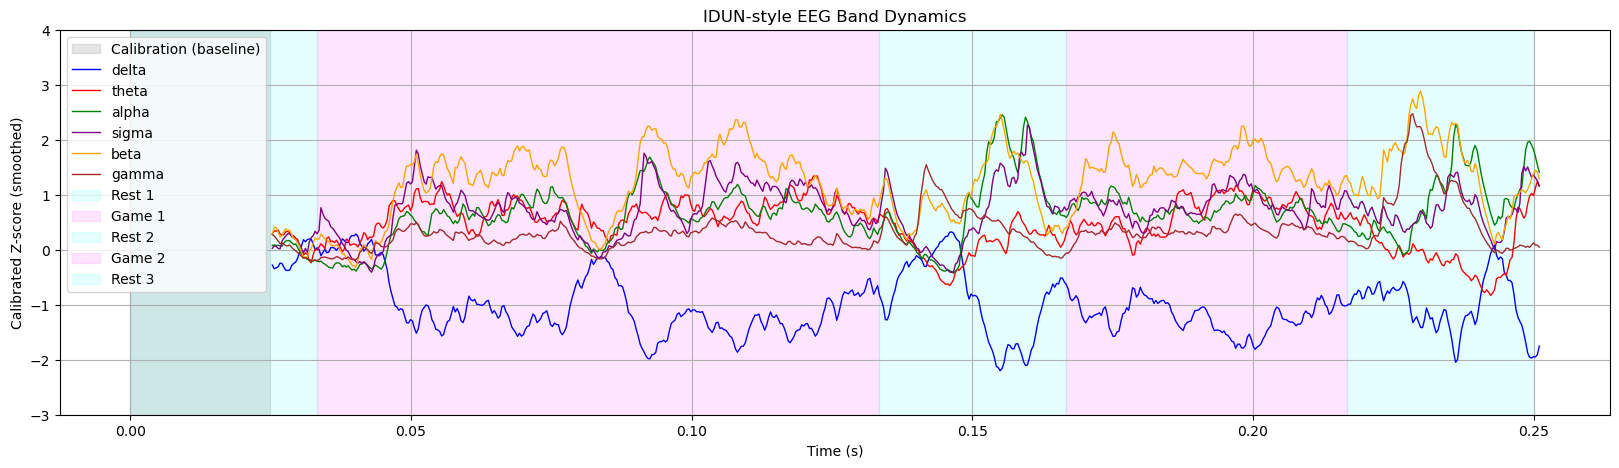

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch
from scipy.integrate import trapezoid

# ---------------------------------------------------
# ASSUMPTIONS
# ---------------------------------------------------
# x_filt = your filtered EEG signal (1D numpy array)
# fs = sampling rate (e.g. 250)

fs = 250

# ---------------------------------------------------
# Band power function
# ---------------------------------------------------
def band_power(freqs, psd, low, high):
    mask = (freqs >= low) & (freqs < high)
    if np.sum(mask) == 0:
        return 0.0
    return trapezoid(psd[mask], freqs[mask])

# ---------------------------------------------------
# Parameters (IDUN-like settings)
# ---------------------------------------------------
window_size = 5 * fs
step_size = int(window_size * 0.25)  # 75% overlap

bands = ["delta", "theta", "alpha", "sigma", "beta", "gamma"]

# ---------------------------------------------------
# FEATURE EXTRACTION (PSD-based)
# ---------------------------------------------------
features = []

for i in range(0, len(x_filt) - window_size, step_size):
    segment = x_filt[i:i + window_size]

    freqs, psd = welch(
        segment,
        fs=fs,
        nperseg=fs * 4,
        noverlap=fs * 2,
    )

    eps = 1e-8
    features.append([
        band_power(freqs, psd, 0.5, 4) + eps,   # delta
        band_power(freqs, psd, 4, 8) + eps,     # theta
        band_power(freqs, psd, 8, 12) + eps,    # alpha
        band_power(freqs, psd, 12, 15) + eps,   # sigma
        band_power(freqs, psd, 15, 30) + eps,   # beta
        band_power(freqs, psd, 30, 35) + eps,   # gamma
    ])

# ---------------------------------------------------
# DATAFRAME
# ---------------------------------------------------
df = pd.DataFrame(features, columns=bands)

df["time_sec"] = np.arange(len(df)) * (step_size / fs)
df["time_hr"] = df["time_sec"] / 3600

# ---------------------------------------------------
# RELATIVE POWER
# ---------------------------------------------------
df["total"] = df[bands].sum(axis=1)

for b in bands:
    df[f"{b}_rel"] = df[b] / df["total"]


# ---------------------------------------------------
# CALIBRATION (IDUN-style baseline)
# ---------------------------------------------------
calibration_time = 90
cutoff_idx = int(calibration_time / (step_size / fs))

cal_df = df.iloc[:cutoff_idx]

baseline_mean = cal_df[[f"{b}_rel" for b in bands]].mean()
baseline_std = cal_df[[f"{b}_rel" for b in bands]].std().replace(0, 1e-8)

# ---------------------------------------------------
# Z-SCORE + SMOOTHING (IDUN-like output layer)
# ---------------------------------------------------
for b in bands:
    rel = f"{b}_rel"

    df[f"{b}_z"] = (df[rel] - baseline_mean[rel]) / baseline_std[rel]

    # exponential smoothing (wearable EEG style)
    df[f"{b}_smooth"] = df[f"{b}_z"].ewm(span=25).mean()

# ---------------------------------------------------
# VISUALIZATION (IDUN STYLE)
# ---------------------------------------------------
colors = {
    "delta": "blue",
    "theta": "red",
    "alpha": "green",
    "sigma": "purple",
    "beta": "orange",
    "gamma": "brown"
}

plt.figure(figsize=(20, 5))

# Calibration block (grey)
plt.axvspan(
    0,
    df["time_hr"].iloc[cutoff_idx], # or time_sec for seconds
    color="grey",
    alpha=0.2,
    label="Calibration (baseline)"
)

# Hide calibration data from curves (IDUN-style UX)
df_plot = df.copy()
for b in bands:
    df_plot.loc[:cutoff_idx, f"{b}_smooth"] = np.nan

# Plot post-calibration signals
for b in bands:  # IDUN focuses on these 3 bands
    plt.plot(
        df["time_hr"], # or time_sec for seconds
        df_plot[f"{b}_smooth"],
        label=b,
        color=colors[b],
        linewidth=1,
        alpha=1
    )

# plot areas for game and rest periods

# rest 1: 0-2 min
plt.axvspan(0, 2/60, color="cyan", alpha=0.1, label="Rest 1")
# game 1: 2-8 min
plt.axvspan(2/60, 8/60, color="magenta", alpha=0.1, label="Game 1")
# rest 2: 8-10 min
plt.axvspan(8/60, 10/60, color="cyan", alpha=0.1, label="Rest 2")
# game 2: 10-13 min
plt.axvspan(10/60, 13/60, color="magenta", alpha=0.1, label="Game 2")
# rest 3: 13-15 min
plt.axvspan(13/60, 15/60, color="cyan", alpha=0.1, label="Rest 3")
plt.xlabel("Time (s)")
plt.ylabel("Calibrated Z-score (smoothed)")
plt.title("IDUN-style EEG Band Dynamics")
plt.legend()
plt.grid()
plt.ylim(-3, 4)
plt.show()

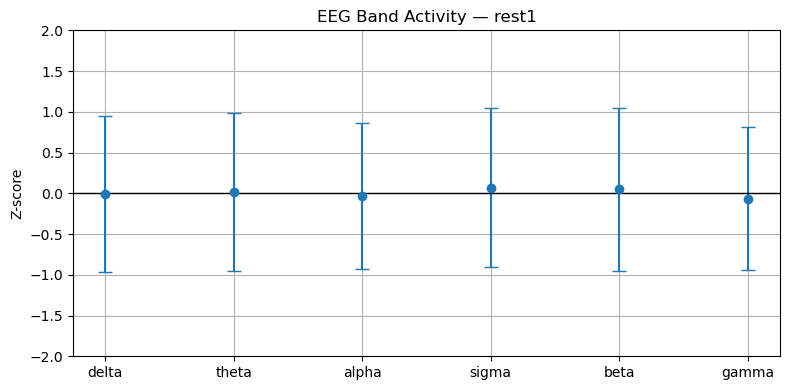

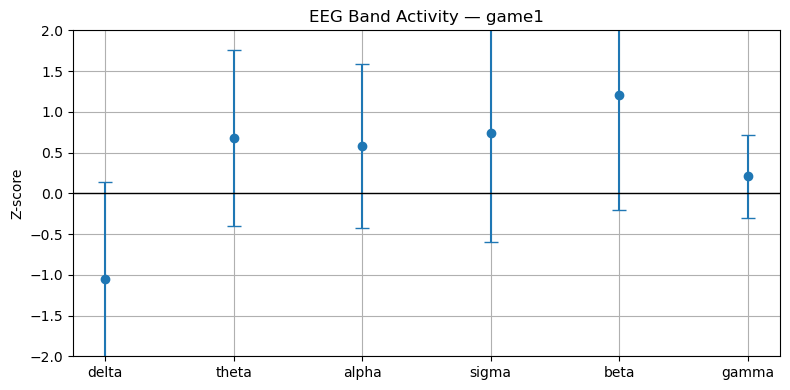

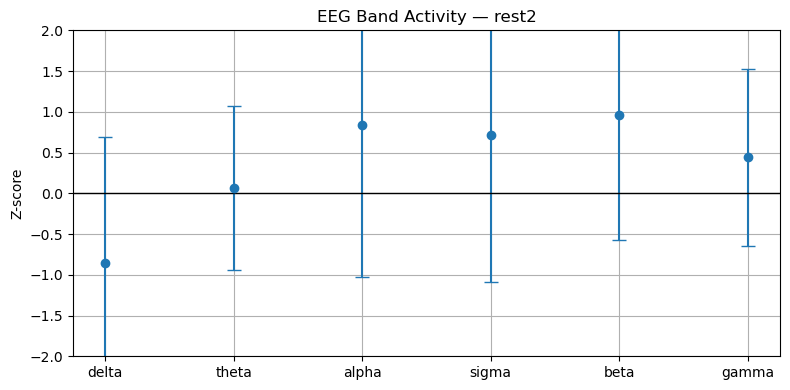

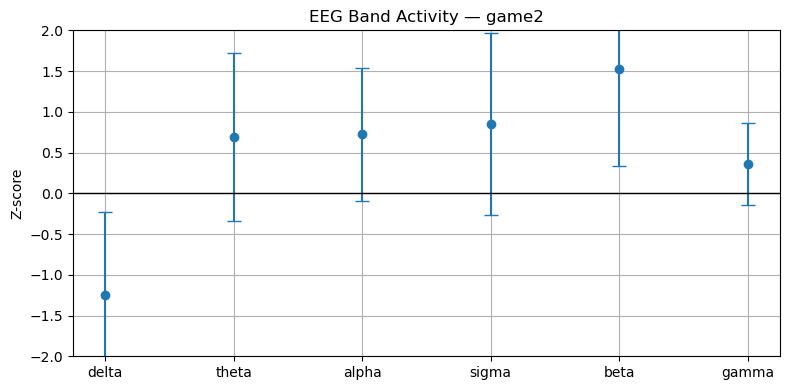

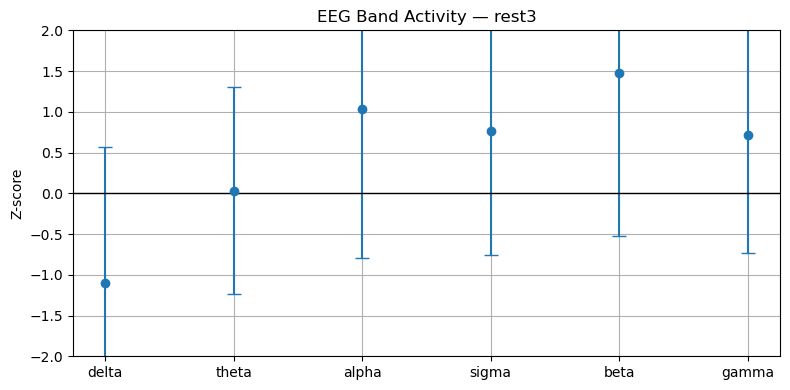

rest1:
  delta: -0.01 ± 0.96
  theta: 0.02 ± 0.97
  alpha: -0.03 ± 0.89
  sigma: 0.07 ± 0.98
  beta: 0.05 ± 1.00
  gamma: -0.07 ± 0.87
game1:
  delta: -1.05 ± 1.19
  theta: 0.68 ± 1.08
  alpha: 0.58 ± 1.01
  sigma: 0.74 ± 1.33
  beta: 1.21 ± 1.41
  gamma: 0.21 ± 0.51
rest2:
  delta: -0.85 ± 1.54
  theta: 0.06 ± 1.01
  alpha: 0.84 ± 1.87
  sigma: 0.71 ± 1.80
  beta: 0.97 ± 1.54
  gamma: 0.44 ± 1.09
game2:
  delta: -1.25 ± 1.03
  theta: 0.69 ± 1.03
  alpha: 0.73 ± 0.82
  sigma: 0.86 ± 1.12
  beta: 1.53 ± 1.19
  gamma: 0.36 ± 0.50
rest3:
  delta: -1.11 ± 1.68
  theta: 0.03 ± 1.27
  alpha: 1.03 ± 1.82
  sigma: 0.76 ± 1.52
  beta: 1.47 ± 1.99
  gamma: 0.72 ± 1.45


In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# SEGMENTS (seconds)
# ---------------------------------------------------
segments = {
    "rest1": (0, 2*60),
    "game1": (2*60, 8*60),
    "rest2": (8*60, 10*60),
    "game2": (10*60, 13*60),
    "rest3": (13*60, 15*60),
}

bands = ["delta", "theta", "alpha", "sigma", "beta", "gamma"]
z_bands = [f"{b}_z" for b in bands]

# ---------------------------------------------------
# LOOP THROUGH EACH SEGMENT
# ---------------------------------------------------
for name, (start, end) in segments.items():

    seg_df = df[(df["time_sec"] >= start) & (df["time_sec"] < end)]

    mean = seg_df[z_bands].mean()
    std = seg_df[z_bands].std()

    x = np.arange(len(bands))

    plt.figure(figsize=(8, 4))

    plt.errorbar(
        x,
        mean.values,
        yerr=std.values,
        fmt='o',
        capsize=5
    )

    plt.xticks(x, bands)
    plt.axhline(0, color="black", linewidth=1)

    plt.title(f"EEG Band Activity — {name}")
    plt.ylabel("Z-score")
    plt.grid()
    plt.ylim(-2, 2)
    plt.tight_layout()

    plt.show()
# print numeric values for each segment
for name, (start, end) in segments.items():
    seg_df = df[(df["time_sec"] >= start) & (df["time_sec"] < end)]
    mean = seg_df[z_bands].mean()
    std = seg_df[z_bands].std()
    print(f"{name}:")
    for b in bands:
        print(f"  {b}: {mean[f'{b}_z']:.2f} ± {std[f'{b}_z']:.2f}")

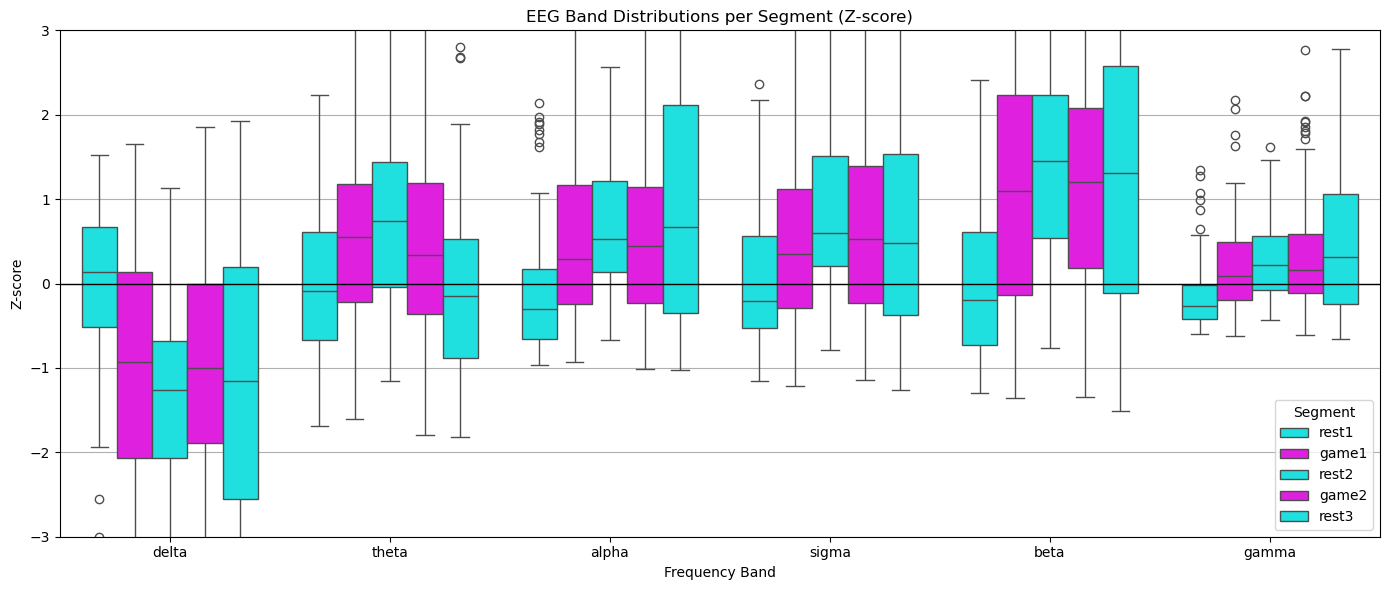

C:\Users\ruegg\AppData\Local\Temp\ipykernel_6484\1432331103.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ruegg\AppData\Local\Temp\ipykernel_6484\1432331103.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ruegg\AppData\Local\Temp\ipykernel_6484\1432331103.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\ruegg\AppData\Local\Temp\ipykernel_6484\1432331103.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` varia

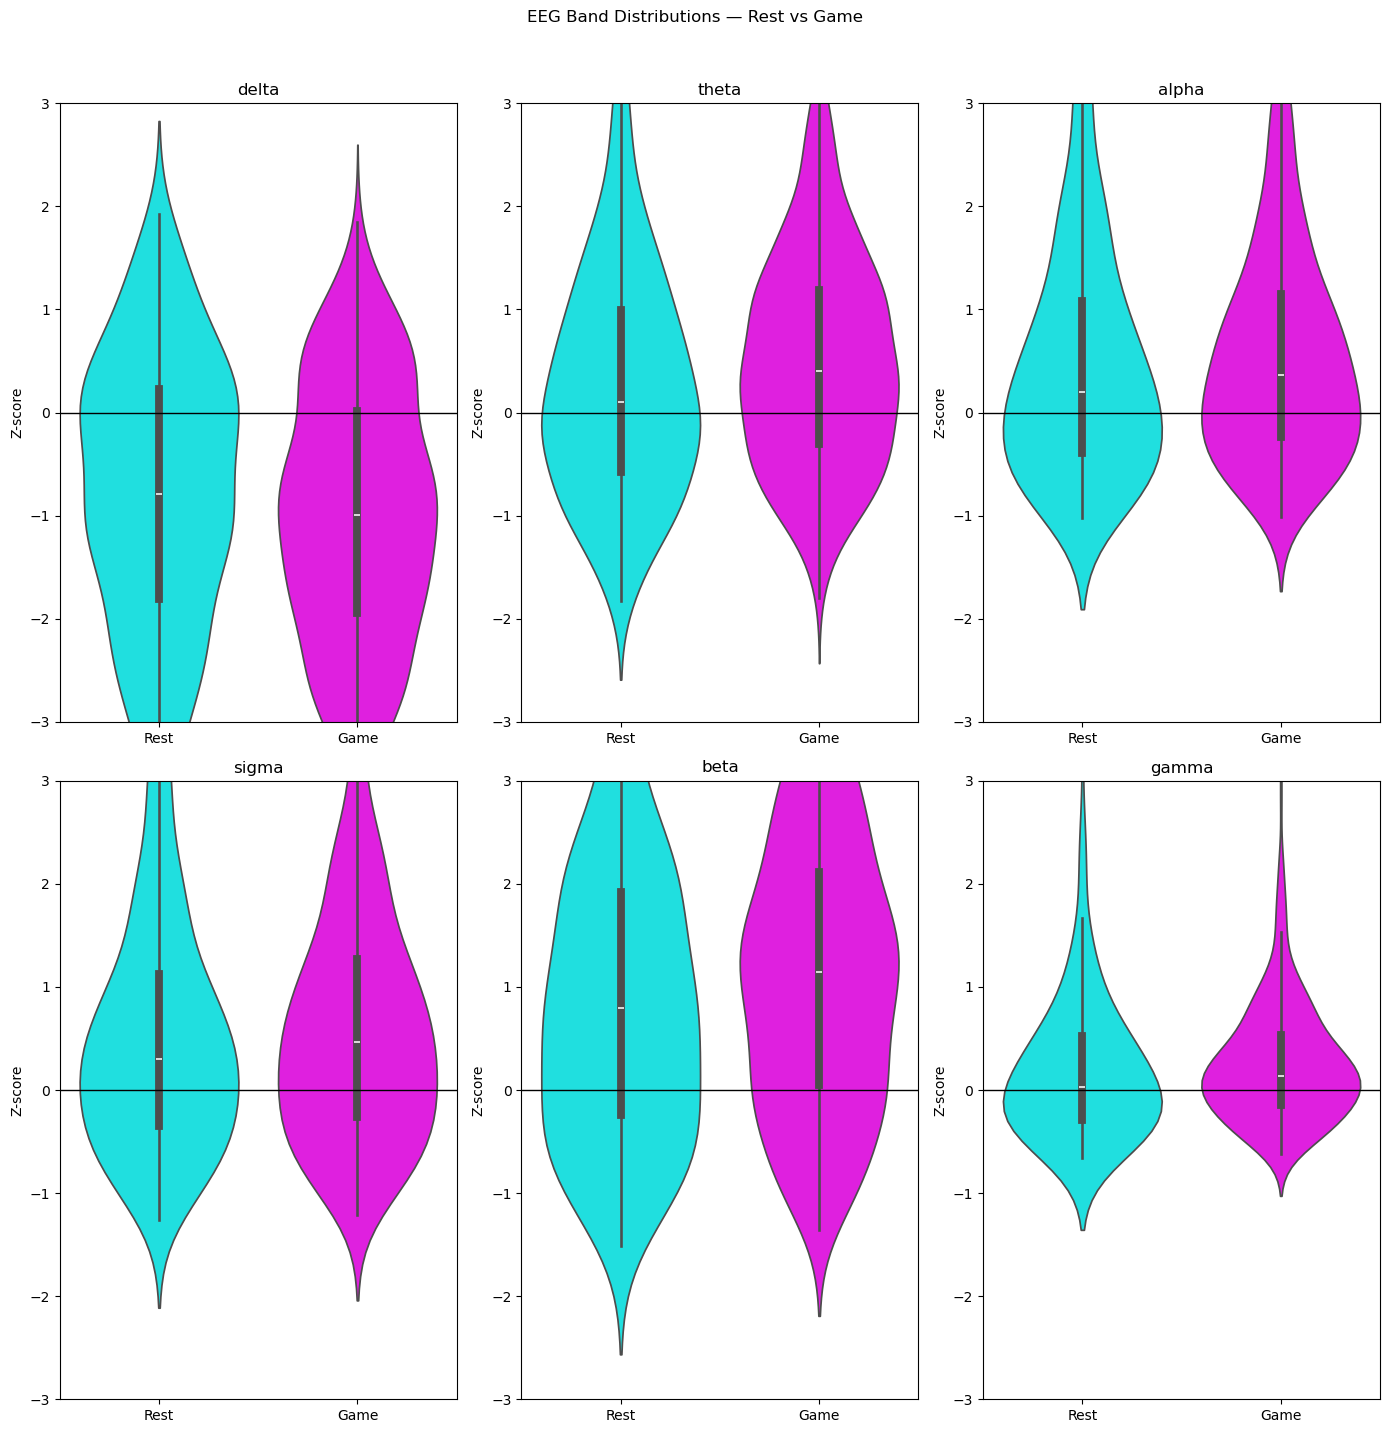

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------
# MANUAL SEGMENT COLORS
# ---------------------------------------------------
segment_colors = {
    "rest1": "cyan",
    "game1": "magenta",
    "rest2": "cyan",
    "game2": "magenta",
    "rest3": "cyan"
}
# ---------------------------------------------------
# SEGMENTS (seconds)
# ---------------------------------------------------
segments = {
    "rest1": (0, 2*60),
    "game1": (2*60, 5.5*60),
    "rest2": (5.5*60, 7.5*60),
    "game2": (7.5*60, 13.3*60),
    "rest3": (13.3*60, 15.3*60),
}

bands = ["delta", "theta", "alpha", "sigma", "beta", "gamma"]
z_bands = [f"{b}_z" for b in bands]

# ---------------------------------------------------
# ASSIGN SEGMENT LABELS
# ---------------------------------------------------
df["segment"] = "other"

for name, (start, end) in segments.items():
    mask = (df["time_sec"] >= start) & (df["time_sec"] < end)
    df.loc[mask, "segment"] = name

# ---------------------------------------------------
# MELT DATA (required for seaborn boxplot)
# ---------------------------------------------------
plot_df = df[df["segment"] != "other"].copy()

melted = plot_df.melt(
    id_vars=["segment"],
    value_vars=z_bands,
    var_name="band",
    value_name="zscore"
)

melted["band"] = melted["band"].str.replace("_z", "")

# ---------------------------------------------------
# BOX + WHISKER PLOT
# ---------------------------------------------------
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted,
    x="band",
    y="zscore",
    hue="segment",
    palette=segment_colors
)

plt.axhline(0, color="black", linewidth=1)

plt.title("EEG Band Distributions per Segment (Z-score)")
plt.ylabel("Z-score")
plt.xlabel("Frequency Band")

plt.legend(title="Segment")
plt.grid(axis="y")
plt.ylim(-3, 3)
plt.tight_layout()

plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

bands = ["delta", "theta", "alpha", "sigma", "beta", "gamma"]

# ensure combined label exists
rests = ["rest1", "rest2", "rest3"]
games = ["game1", "game2"]

melted["segment_combined"] = melted["segment"].apply(
    lambda x: "Rest" if x in rests else ("Game" if x in games else "Other")
)

plot_df = melted[melted["segment_combined"] != "Other"]

# ---------------------------------------------------
# FIGURE: one subplot per band
# ---------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 14))
axes = axes.flatten()

palette = {"Rest": "cyan", "Game": "magenta"}

for i, b in enumerate(bands):

    sns.violinplot(
        data=plot_df[plot_df["band"] == b],
        x="segment_combined",
        y="zscore",
        palette=palette,
        ax=axes[i]
    )

    axes[i].axhline(0, color="black", linewidth=1)
    axes[i].set_title(f"{b}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Z-score")
    axes[i].set_ylim(-3, 3)

plt.suptitle("EEG Band Distributions — Rest vs Game", y=1.02)
plt.tight_layout()
plt.show()

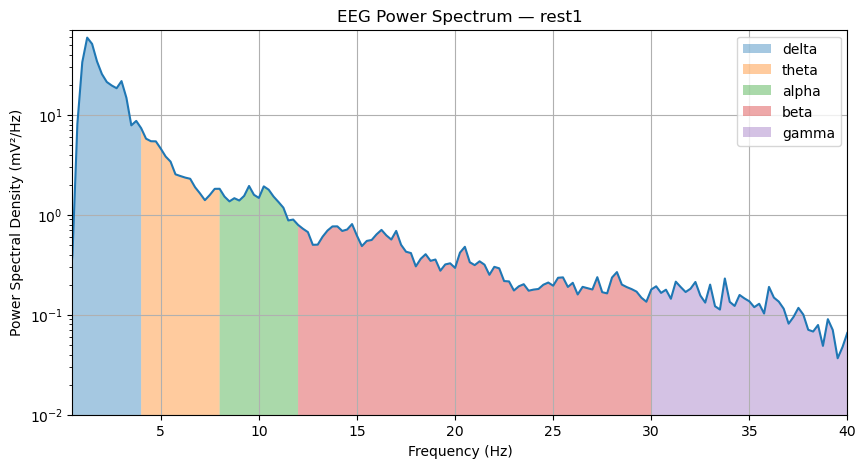

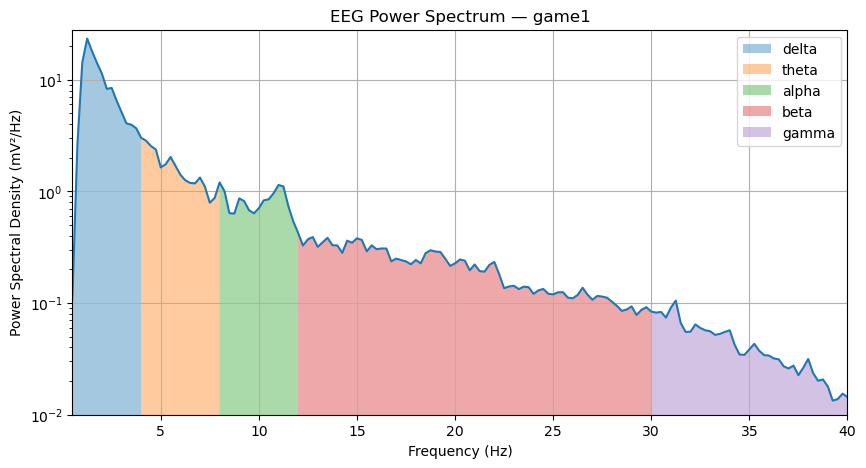

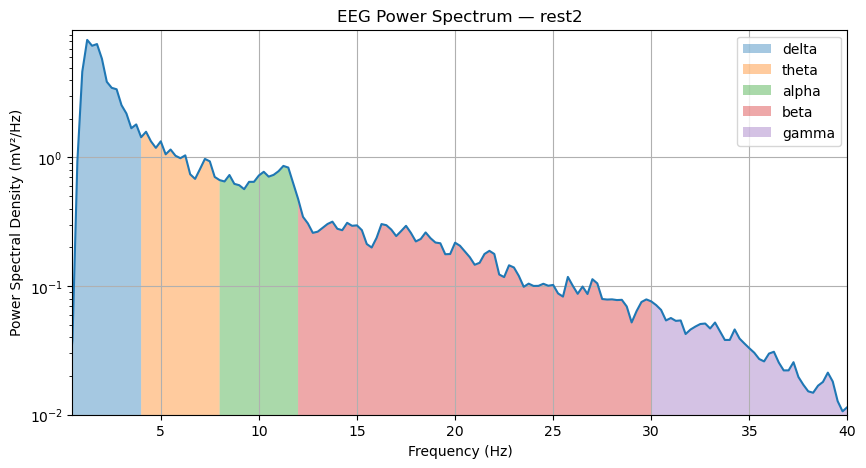

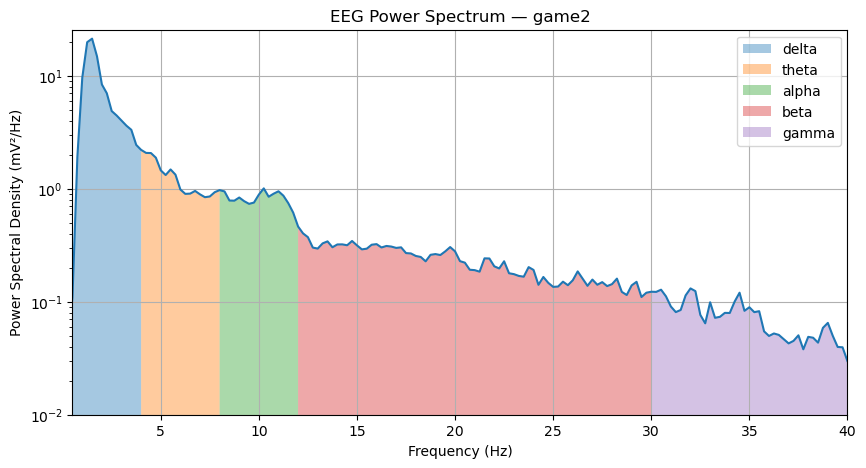

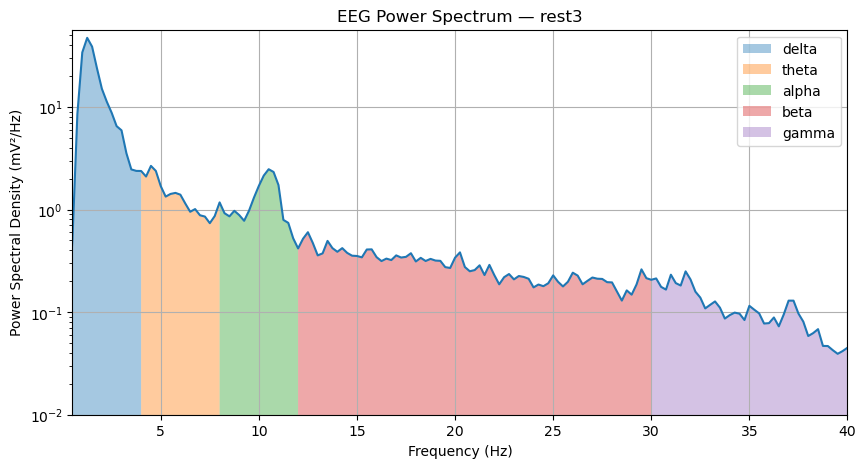

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

fs = 250

# ---------------------------------------------------
# DEFINE SEGMENTS (seconds)
# ---------------------------------------------------
segments = {
    "rest1": (0, 2*60),
    "game1": (2*60, 5.5*60),
    "rest2": (5.5*60, 7.5*60),
    "game2": (7.5*60, 13.3*60),
    "rest3": (13.3*60, 15.3*60),
}

# ---------------------------------------------------
# BAND DEFINITIONS
# ---------------------------------------------------
bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (12, 30),
    "gamma": (30, 40)
}

# ---------------------------------------------------
# LOOP THROUGH SEGMENTS
# ---------------------------------------------------
for name, (start, end) in segments.items():

    # convert time → indices
    seg = x_filt[int(start*fs):int(end*fs)]

    freqs, psd = welch(
        seg,
        fs=fs,
        nperseg=fs * 4,
        noverlap=fs * 2
    )

    plt.figure(figsize=(10, 5))

    plt.semilogy(freqs, psd)

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power Spectral Density (mV²/Hz)")
    plt.title(f"EEG Power Spectrum — {name}")

    plt.grid(True)

    plt.xlim([0.5, 40])

    # optional fixed visibility range (safe for EEG)
    plt.ylim([0.01, np.max(psd) * 1.2])

    # ---------------------------------------------------
    # FILL BAND AREAS
    # ---------------------------------------------------
    for band, (f_low, f_high) in bands.items():
        mask = (freqs >= f_low) & (freqs <= f_high)

        if np.any(mask):
            plt.fill_between(
                freqs[mask],
                psd[mask],
                alpha=0.4,
                label=band
            )

    plt.legend()
    plt.show()


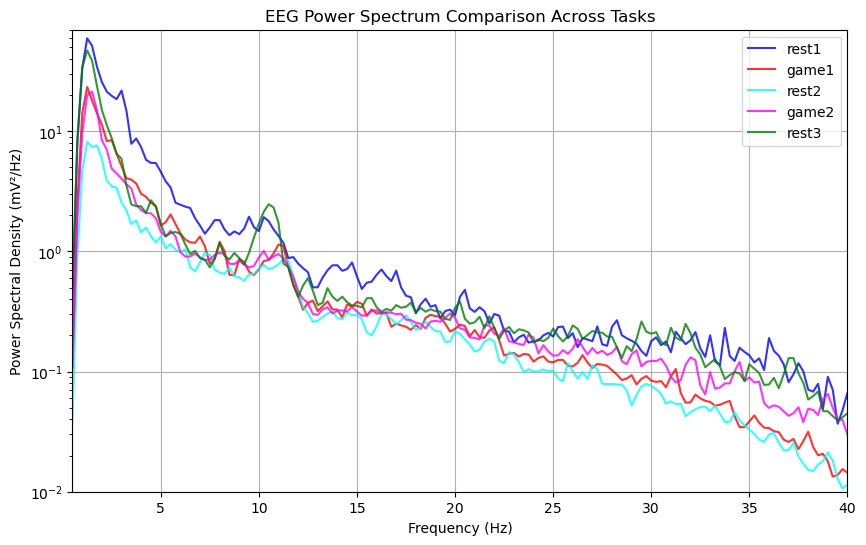

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

fs = 250

segments = {
    "rest1": (0, 2*60),
    "game1": (2*60, 5.5*60),
    "rest2": (5.5*60, 7.5*60),
    "game2": (7.5*60, 13.3*60),
    "rest3": (13.3*60, 15.3*60),
}

colors = {
    "rest1": "blue",
    "game1": "red",
    "rest2": "cyan",
    "game2": "magenta",
    "rest3": "green"
}

plt.figure(figsize=(10, 6))

for name, (start, end) in segments.items():

    seg = x_filt[int(start*fs):int(end*fs)]

    freqs, psd = welch(
        seg,
        fs=fs,
        nperseg=fs * 4,
        noverlap=fs * 2
    )

    plt.semilogy(freqs, psd, label=name, color=colors[name], alpha=0.8)

# ---------------------------------------------------
# Styling
# ---------------------------------------------------
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (mV²/Hz)")
plt.title("EEG Power Spectrum Comparison Across Tasks")

plt.xlim(0.5, 40)
plt.ylim(0.01, 70)  # auto upper limit, fixed lower limit for visibility
plt.grid(True)
plt.legend()

plt.show()


EEG Band Power (% per segment):

       delta  theta  alpha  sigma  beta  gamma
rest1  75.63  11.74   5.32   1.87  4.23   1.21
game1  69.06  14.41   7.15   2.31  6.09   0.97
rest2  56.36  17.21  11.49   3.76  9.72   1.47
game2  66.84  12.80   8.23   2.52  7.74   1.86
rest3  75.58   8.18   7.19   1.86  5.55   1.64


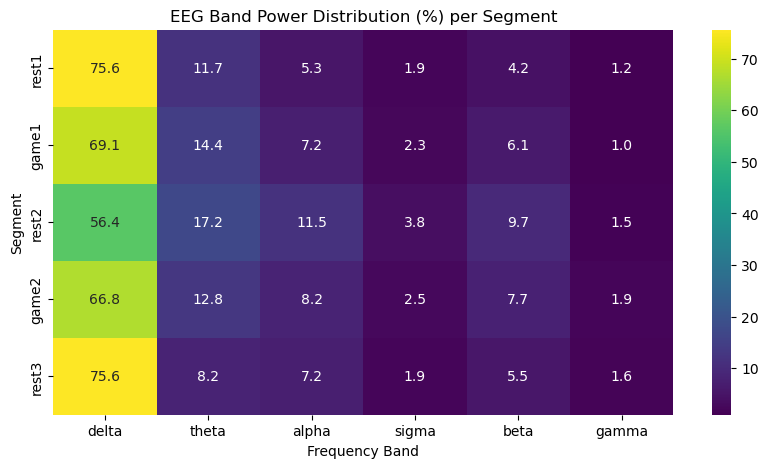

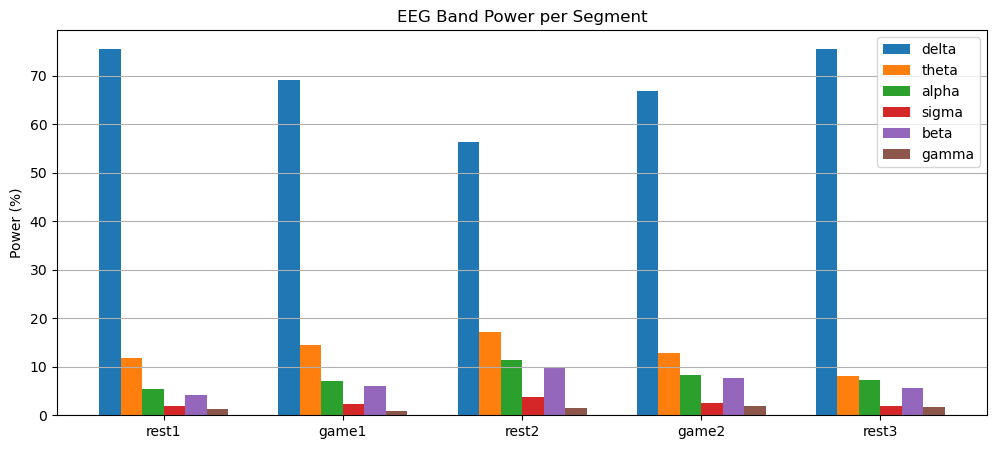

In [33]:
import numpy as np
import pandas as pd
from scipy.signal import welch

fs = 250

segments = {
    "rest1": (0, 2*60),
    "game1": (2*60, 5.5*60),
    "rest2": (5.5*60, 7.5*60),
    "game2": (7.5*60, 13.3*60),
    "rest3": (13.3*60, 15.3*60),
}

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "sigma": (12, 15),
    "beta": (15, 30),
    "gamma": (30, 40)
}

from scipy.integrate import trapezoid

def band_power(freqs, psd, low, high):
    mask = (freqs >= low) & (freqs <= high)

    if np.sum(mask) == 0:
        return 0.0

    return trapezoid(psd[mask], freqs[mask])
results = {}

for name, (start, end) in segments.items():

    seg = x_filt[int(start*fs):int(end*fs)]

    freqs, psd = welch(
        seg,
        fs=fs,
        nperseg=fs * 4,
        noverlap=fs * 2
    )

    band_powers = {}

    for b, (low, high) in bands.items():
        band_powers[b] = band_power(freqs, psd, low, high)

    total_power = sum(band_powers.values()) + 1e-12

    band_percent = {b: (p / total_power) * 100 for b, p in band_powers.items()}

    results[name] = band_percent

# ---------------------------------------------------
# TABLE OUTPUT
# ---------------------------------------------------
df_percent = pd.DataFrame(results).T

print("\nEEG Band Power (% per segment):\n")
print(df_percent.round(2))

# visualisation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.heatmap(
    df_percent,
    annot=True,
    cmap="viridis",
    fmt=".1f"
)

plt.title("EEG Band Power Distribution (%) per Segment")
plt.ylabel("Segment")
plt.xlabel("Frequency Band")
plt.show()

import numpy as np
import matplotlib.pyplot as plt

bands = df_percent.columns
segments = df_percent.index

x = np.arange(len(segments))
width = 0.12

plt.figure(figsize=(12, 5))

for i, b in enumerate(bands):
    plt.bar(
        x + i * width,
        df_percent[b],
        width=width,
        label=b
    )

plt.xticks(x + width * 2.5, segments)
plt.ylabel("Power (%)")
plt.title("EEG Band Power per Segment")
plt.legend()
plt.grid(axis="y")
plt.show()


EEG Band Activity (relative to mean):

       delta  theta  alpha  sigma   beta  gamma
rest1  0.995  0.865  0.441  0.619  0.383  0.650
game1 -0.242 -0.047 -0.193 -0.168 -0.172 -0.448
rest2 -0.671 -0.394 -0.310 -0.281 -0.296 -0.557
game2 -0.350 -0.250 -0.178 -0.196 -0.068 -0.064
rest3  0.268 -0.174  0.239  0.025  0.153  0.419


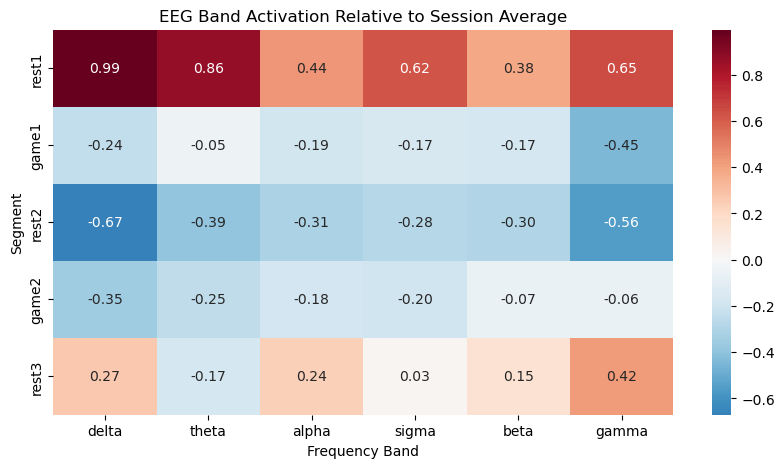

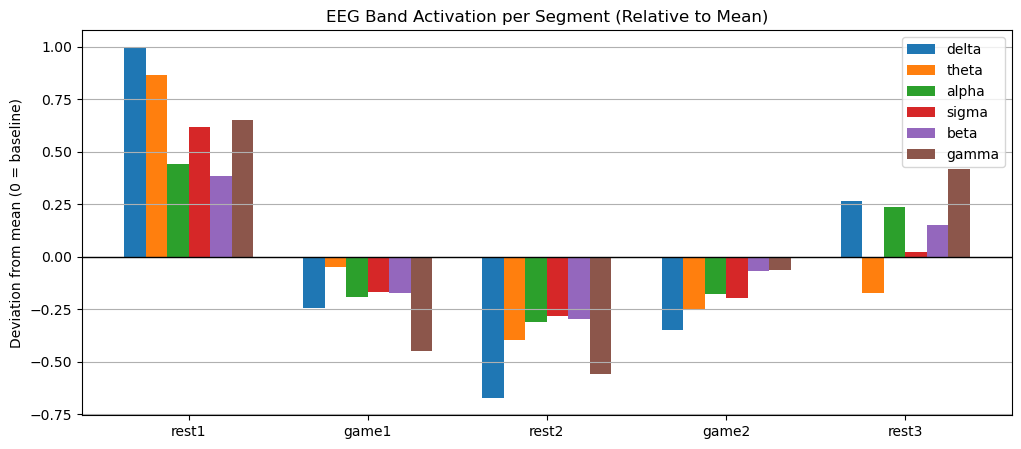

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from scipy.integrate import trapezoid

fs = 250

# ---------------------------------------------------
# SEGMENTS (seconds)
# ---------------------------------------------------
segments = {
    "rest1": (0, 2*60),
    "game1": (2*60, 5.5*60),
    "rest2": (5.5*60, 7.5*60),
    "game2": (7.5*60, 13.3*60),
    "rest3": (13.3*60, 15.3*60),
}

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "sigma": (12, 15),
    "beta": (15, 30),
    "gamma": (30, 40)
}

# ---------------------------------------------------
# BAND POWER FUNCTION
# ---------------------------------------------------
def band_power(freqs, psd, low, high):
    mask = (freqs >= low) & (freqs <= high)
    if np.sum(mask) == 0:
        return 0.0
    return trapezoid(psd[mask], freqs[mask])

# ---------------------------------------------------
# FEATURE EXTRACTION PER SEGMENT
# ---------------------------------------------------
results_raw = {}

for name, (start, end) in segments.items():

    seg = x_filt[int(start*fs):int(end*fs)]

    freqs, psd = welch(
        seg,
        fs=fs,
        nperseg=fs * 4,
        noverlap=fs * 2
    )

    band_powers = {}

    for b, (low, high) in bands.items():
        band_powers[b] = band_power(freqs, psd, low, high)

    results_raw[name] = band_powers

# ---------------------------------------------------
# DATAFRAME
# ---------------------------------------------------
df_raw = pd.DataFrame(results_raw).T

# ---------------------------------------------------
# NORMALISATION (KEY PART)
# each band compared to its own mean across all segments
# ---------------------------------------------------
band_means = df_raw.mean()

df_norm = df_raw / band_means

# convert to "activation vs baseline"
df_norm = df_norm - 1.0

print("\nEEG Band Activity (relative to mean):\n")
print(df_norm.round(3))

# ---------------------------------------------------
# HEATMAP
# ---------------------------------------------------
plt.figure(figsize=(10, 5))

sns.heatmap(
    df_norm,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)

plt.title("EEG Band Activation Relative to Session Average")
plt.ylabel("Segment")
plt.xlabel("Frequency Band")
plt.show()

# ---------------------------------------------------
# BAR PLOT
# ---------------------------------------------------
bands_list = df_norm.columns
segments_list = df_norm.index

x = np.arange(len(segments_list))
width = 0.12

plt.figure(figsize=(12, 5))

for i, b in enumerate(bands_list):
    plt.bar(
        x + i * width,
        df_norm[b],
        width=width,
        label=b
    )

plt.axhline(0, color="black", linewidth=1)

plt.xticks(x + width * 2.5, segments_list)
plt.ylabel("Deviation from mean (0 = baseline)")
plt.title("EEG Band Activation per Segment (Relative to Mean)")
plt.legend()
plt.grid(axis="y")
plt.show()